# Auto-sklearn House Price Prediction Modeling

This notebook implements:
1. Data loading and preprocessing using the project pipeline
2. Auto-sklearn regression modeling
3. Baseline comparison with Random Forest and XGBoost
4. Performance evaluation and residual analysis
5. Regional error analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import autosklearn.regression
import joblib
import os

# Local imports
from utils_preprocessing import prepare_data
from utils_data_io import load_housing_data

## 1. Load and Preprocess Data

In [2]:
DATA_PATH = "data/raw/india_housing_prices.csv"

# load and process data
# handles cleaning, splitting, encoding, and scaling
X_train, X_test, y_train, y_test, preprocessor, feature_names = prepare_data(
    data_path=DATA_PATH,
    test_size=0.2,
    random_state=42
)

# use full dataset
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (200000, 594)
Test set shape: (50000, 594)


## 2. Auto-sklearn Model

In [3]:
# configure autosklearn
automl = autosklearn.regression.AutoSklearnRegressor(
    time_left_for_this_task=1800,  # 5 minutes for demo purposes
    per_run_time_limit=120,
    n_jobs=1,
    seed=42,
    memory_limit=10240,
)

# train autosklearn
print("Training Autosklearn regressor")
automl.fit(X_train, y_train)

# print statistics
print(automl.sprint_statistics())

Training Autosklearn regressor
[WARNING] [2025-12-02 21:03:50,092:Client-EnsembleBuilder] No runs were available to build an ensemble from
[WARNING] [2025-12-02 21:05:51,977:Client-EnsembleBuilder] No runs were available to build an ensemble from
[WARNING] [2025-12-02 21:06:07,003:Client-EnsembleBuilder] No runs were available to build an ensemble from
[WARNING] [2025-12-02 21:06:10,061:Client-EnsembleBuilder] No runs were available to build an ensemble from
[WARNING] [2025-12-02 21:06:19,238:Client-EnsembleBuilder] No runs were available to build an ensemble from
[WARNING] [2025-12-02 21:06:35,193:Client-EnsembleBuilder] No runs were available to build an ensemble from
[WARNING] [2025-12-02 21:08:36,527:Client-EnsembleBuilder] No runs were available to build an ensemble from
[WARNING] [2025-12-02 21:08:50,484:Client-EnsembleBuilder] No runs were available to build an ensemble from
[WARNING] [2025-12-02 21:10:51,755:Client-EnsembleBuilder] No runs were available to build an ensemble fr

## 3. Baseline Models

In [4]:
# random forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
print("Training Random Forest")
rf_model.fit(X_train, y_train)

# xgboost
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
print("Training XGBoost")
xgb_model.fit(X_train, y_train)

Training Random Forest
Training XGBoost


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

## 4. Evaluation & Comparison

In [5]:
models = {
    "Auto-sklearn": automl,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

results = []
predictions = {}

for name, model in models.items():
    # predict
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    
    # calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse
    })

results_df = pd.DataFrame(results)
print(results_df)

           Model       MAE      RMSE
0   Auto-sklearn  6.965843  8.834875
1  Random Forest  6.924729  8.931115
2        XGBoost  7.276090  9.166096


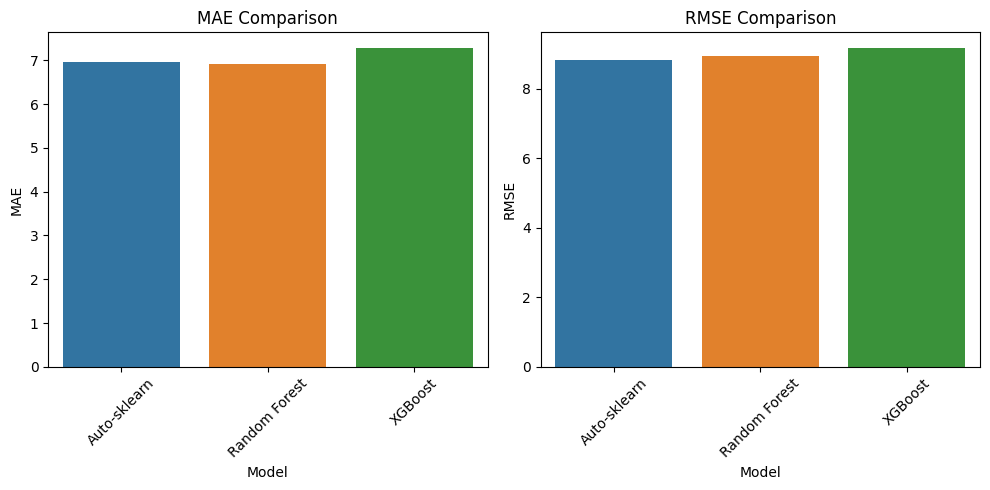

In [6]:
# visualization of metrics
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.barplot(data=results_df, x="Model", y="MAE", hue="Model")
plt.title("MAE Comparison")
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.barplot(data=results_df, x="Model", y="RMSE", hue="Model")
plt.title("RMSE Comparison")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 5. Residual Analysis (Best Model)

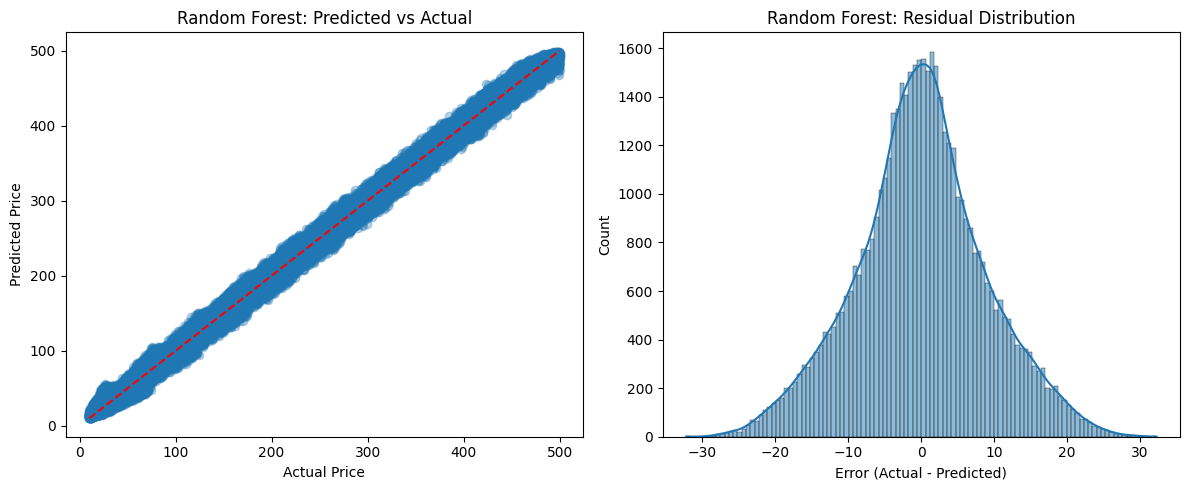

In [7]:
# select best model based on MAE
best_model_name = results_df.sort_values("MAE").iloc[0]["Model"]
best_preds = predictions[best_model_name]

residuals = y_test - best_preds

plt.figure(figsize=(12, 5))

# predicted vs actual
plt.subplot(1, 2, 1)
plt.scatter(y_test, best_preds, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"{best_model_name}: Predicted vs Actual")

# residual distribution
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True)
plt.title(f"{best_model_name}: Residual Distribution")
plt.xlabel("Error (Actual - Predicted)")

plt.tight_layout()
plt.show()

## 6. Regional Analysis

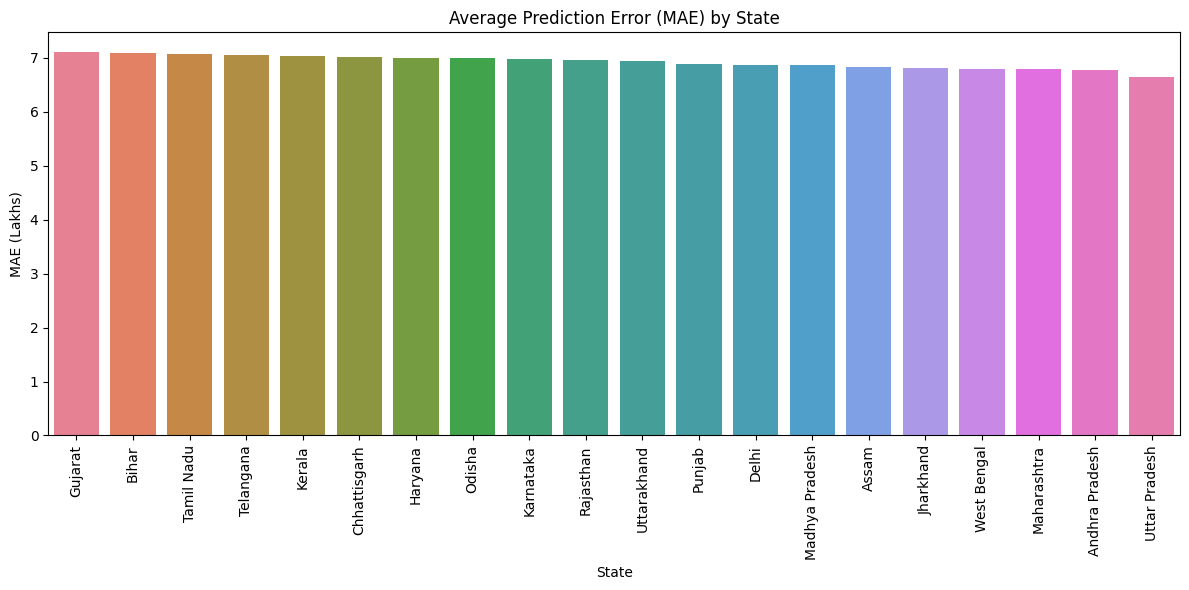

In [8]:
# recover original metadata for the test set
full_df = load_housing_data(DATA_PATH)
test_metadata = full_df.loc[y_test.index].copy()

# add predictions and errors
test_metadata["Predicted_Price"] = best_preds
test_metadata["Absolute_Error"] = np.abs(test_metadata["Price_in_Lakhs"] - test_metadata["Predicted_Price"])

# calculate MAE by state
state_errors = test_metadata.groupby("State")["Absolute_Error"].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=state_errors.index, y=state_errors.values, hue=state_errors.index)
plt.xticks(rotation=90)
plt.title("Average Prediction Error (MAE) by State")
plt.ylabel("MAE (Lakhs)")
plt.tight_layout()
plt.show()

In [9]:
# save the best model
os.makedirs("models", exist_ok=True)
model_filename = f"models/best_model_{best_model_name.replace(' ', '_').lower()}.pkl"
joblib.dump(models[best_model_name], model_filename)
print(f"Saved best model to {model_filename}")

Saved best model to models/best_model_random_forest.pkl
